# Project: Investigate a Dataset - No-show Appointments

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
</ul>

<a id='intro'></a>
## Introduction


### Question(s) for Analysis

> The questions that we will explore in this report are:
>- How does the percentage of no-show appointments compare to appointments that were attended?
>- What is the relationship between no-show appointments and gender?
>- What is the relationship between no-show appointments and alcoholism?
>- What is the relationship between no-show appointments and SMS text reminders?
>
>This report has a dependent variable, which is the variable that is being measured. The dependent variable is the no-show appointments. The independent variables are gender, alcoholism, and SMS text reminders. 

In [1]:
#Imports packages necessary for the report 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

<a id='wrangling'></a>
## Data Wrangling

### General Properties

In [2]:
# Loads the data with pandas 
df = pd.read_csv('noshow.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# Lists the number of rows and columns 
size = df.shape
print('Number of rows:', size[0])
print('Number of columns:', size[1])

Number of rows: 110527
Number of columns: 14


In [4]:
# prints information about the dataframe 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


### Data Cleaning 

> In this section, we will:
> - check for null values
> - check for duplicated values
> - rename columns that are misspelled
> - change the data types of columns
> - change the values of the no-show column 

In [5]:
# Lists any null values 
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [6]:
# Lists the sum of duplicated values 
df.duplicated().sum()

0

In [7]:
# Rename misspelled columns 
rename_column = df.rename(columns={"Neighbourhood": "Neighborhood", "Hipertension": "Hypertension", "Handcap": "Handicap"}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighborhood    110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hypertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handicap        110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [8]:
# Changes the data type of columns 
df['Gender'] = df['Gender'].astype('category')
df['Neighborhood'] = df['Neighborhood'].astype('category')
df['Scholarship'] = df['Scholarship'].astype('bool')
df['Hypertension'] = df['Hypertension'].astype('bool')
df['Diabetes'] = df['Diabetes'].astype('bool')
df['Alcoholism'] = df['Alcoholism'].astype('bool')
df['Handicap'] = df['Handicap'].astype('bool')
df['SMS_received'] = df['SMS_received'].astype('bool')

# Changes the values of no-show column and its data type 
df['No-show'].replace({'Yes': 1, 'No': 0}, inplace=True)
df['No-show'] = df['No-show'].astype('bool')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   PatientId       110527 non-null  float64 
 1   AppointmentID   110527 non-null  int64   
 2   Gender          110527 non-null  category
 3   ScheduledDay    110527 non-null  object  
 4   AppointmentDay  110527 non-null  object  
 5   Age             110527 non-null  int64   
 6   Neighborhood    110527 non-null  category
 7   Scholarship     110527 non-null  bool    
 8   Hypertension    110527 non-null  bool    
 9   Diabetes        110527 non-null  bool    
 10  Alcoholism      110527 non-null  bool    
 11  Handicap        110527 non-null  bool    
 12  SMS_received    110527 non-null  bool    
 13  No-show         110527 non-null  bool    
dtypes: bool(7), category(2), float64(1), int64(2), object(2)
memory usage: 5.2+ MB


<a id='eda'></a>
## Exploratory Data Analysis

### Research Question 1 - How does the percentage of no-show appointments compare to appointments that were attended? 

In [9]:
# Lists the total number of rows 
total_rows = len(df)
print('Number of rows:', total_rows)

Number of rows: 110527


In [10]:
# Computes the percentage of no-show/show appts
total_show = df['No-show'].value_counts()[0]
total_noshow = df['No-show'].value_counts()[1]
print('Percentage of appointments attended:', np.around(((total_show / total_rows) * 100), 1))
print('Percentage of appointments not attended:', np.around(((total_noshow / total_rows) * 100), 1))

Percentage of appointments attended: 79.8
Percentage of appointments not attended: 20.2


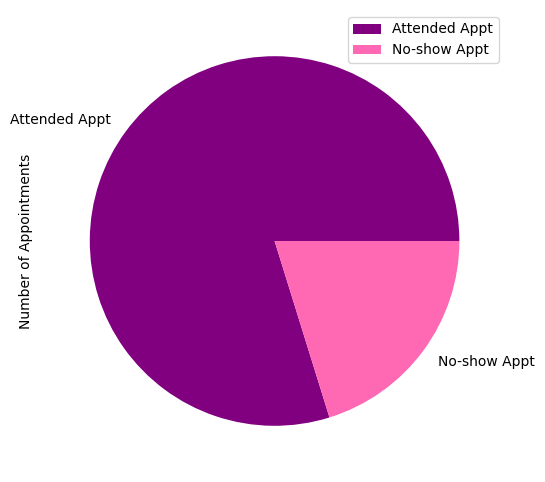

In [28]:
# Plots the number of no-show/show appts 
pie = pd.DataFrame([79.8, 20.2], index=['Attended Appt', 'No-show Appt'], columns=['Number of Appointments'])
colors = ['#800080', '#FF69B4']  # Purple and Pink
pie.plot(kind='pie', subplots=True, figsize=(6, 6), colors=colors)
plt.show()

> The pie chart shows that the amount of appointments attended is greater than the amount of appointments not attended. 

### Research Question 2 - What is the relatioship between no-show appointments and gender? 

In [12]:
# Determines the number of women that did and did not attend appts 
f_show = df.query('Gender =="F"')['No-show'].value_counts()[0]
print('Total number of women that did attend:', f_show)
f_noshow = df.query('Gender == "F"')['No-show'].value_counts()[1]
print('Total number of women that did not attend:', f_noshow)

Total number of women that did attend: 57246
Total number of women that did not attend: 14594


In [13]:
# Creates a function to calculate percentage 
def f(num1, num2):
    f_per = np.around(((num1 / num2) * 100), 1)
    return f_per

In [14]:
# Determines the percentage of women that did and did not attend appts 
f_total = f_show + f_noshow
print('Percentage of appointments attended by women:')
print(f(f_show, f_total))

print('Percentage of appointments not attended by women:')
print(f(f_noshow, f_total))

Percentage of appointments attended by women:
79.7
Percentage of appointments not attended by women:
20.3


In [15]:
# Determines the number of men that did and did not attend appts 
m_show = df.query('Gender == "M"')['No-show'].value_counts()[0]
print('Total number of men that did attend:', m_show)
m_noshow = df.query('Gender == "M"')['No-show'].value_counts()[1]
print('Total number of men that did not attend:', m_noshow)

Total number of men that did attend: 30962
Total number of men that did not attend: 7725


In [16]:
# Determines the percentage of men that did and did not attend appts 
m_total = m_show + m_noshow
print('Percentage of appointments attended by men:')
print(f(m_show, m_total))

print('Percentage of appointments not attended by men:')
print(f(m_noshow, m_total))

Percentage of appointments attended by men:
80.0
Percentage of appointments not attended by men:
20.0


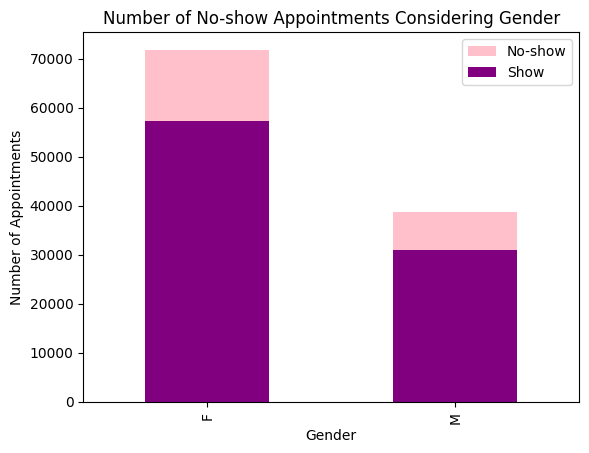

In [17]:
# Plots the number of no-show/show appts by gender 
no_show = df['Gender'].value_counts()
show = df[df['No-show'] == 0]['Gender'].value_counts()
no_show.plot(kind='bar', color='pink')
show.plot(kind='bar', color='purple')
plt.legend(['No-show', 'Show'])
plt.title('Number of No-show Appointments Considering Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Appointments')
plt.show()

> The bar chart shows that women had more appointments than men. For women, it shows that there are more attended appointments than no-show appointments. For men, it shows that there are more attended appointments than no-show appointments. 

### Research Question 3 - What is the relationship between no-show appointments and alcoholism? 

In [18]:
# Determines the number of no-show/show appts by alcoholic and nonalcoholic patients
alcoholic_show = df.query('Alcoholism == 1')['No-show'].value_counts()[0]
print('Total number of alcholics that attended appointments:', alcoholic_show)
alcoholic_noshow = df.query('Alcoholism == 1')['No-show'].value_counts()[1]
print('Total number of alcoholics that did not attend appointments:', alcoholic_noshow)
sober_show = df.query('Alcoholism == 0')['No-show'].value_counts()[0]
print('Total number of nonalcoholics that attended appointments:', sober_show)
sober_noshow = df.query('Alcoholism == 0')['No-show'].value_counts()[1]
print('Total number of nonalcoholics that did not attend appointments:', sober_noshow)

Total number of alcholics that attended appointments: 2683
Total number of alcoholics that did not attend appointments: 677
Total number of nonalcoholics that attended appointments: 85525
Total number of nonalcoholics that did not attend appointments: 21642


In [19]:
# Determines the percentage of no-show/show appts by alcoholic patients
alcoholic_total = alcoholic_show + alcoholic_noshow
print('Percentage of alcoholics that attended appointments:')
print(f(alcoholic_show, alcoholic_total))

print('Percentage of alcoholics that did not attend appointments:')
print(f(alcoholic_noshow, alcoholic_total))

Percentage of alcoholics that attended appointments:
79.9
Percentage of alcoholics that did not attend appointments:
20.1


In [20]:
# Determines the percentage of no-show/show appts by nonalcoholic patients 
sober_total = sober_show + sober_noshow
print('Percentage of nonalcoholics that attended appointments:')
print(f(sober_show, sober_total))

print('Percentage of nonalcoholics that did not attend appointments:')
print(f(sober_noshow, sober_total))

Percentage of nonalcoholics that attended appointments:
79.8
Percentage of nonalcoholics that did not attend appointments:
20.2


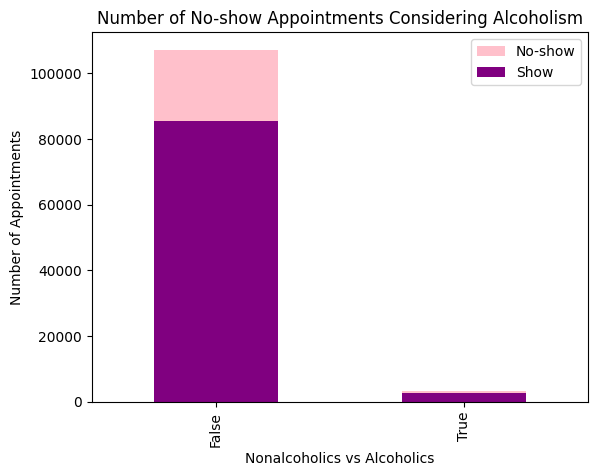

In [21]:
# Plots the number of no-show/show appts by alcoholic and nonalcoholic patients
no_show = df['Alcoholism'].value_counts()
show = df[df['No-show'] == 0]['Alcoholism'].value_counts()
no_show.plot(kind='bar', color='pink')
show.plot(kind='bar', color='purple')
plt.legend(['No-show', 'Show'])
plt.title('Number of No-show Appointments Considering Alcoholism')
plt.xlabel('Nonalcoholics vs Alcoholics')
plt.ylabel('Number of Appointments')
plt.show()

> The bar chart shows that nonalcoholics have more appointments than alcoholics. For nonalcoholics, it shows that there are more attended appointments than no-show appointments. For alcoholics, it shows that there are more attended appointments than no-show appointments. 

### Research Question 4 - What is the relationship between no-show appointments and SMS text reminders? 

In [22]:
# Determines the number of no-show/show appts by patients who did and did not receive text reminders
nosms_show = df.query('SMS_received == 0')['No-show'].value_counts()[0]
print('Total number of patients that attended without an SMS text:', nosms_show)
sms_show = df.query('SMS_received == 1')['No-show'].value_counts()[0]
print('Total number of patients that attended with an SMS text:', sms_show)
nosms_noshow = df.query('SMS_received == 0')['No-show'].value_counts()[1]
print('Total number of patients that did not attend without an SMS text:', nosms_noshow)
sms_noshow = df.query('SMS_received == 1')['No-show'].value_counts()[1]
print('Total number of patients that did not attend with an SMS text:', sms_noshow)

Total number of patients that attended without an SMS text: 62510
Total number of patients that attended with an SMS text: 25698
Total number of patients that did not attend without an SMS text: 12535
Total number of patients that did not attend with an SMS text: 9784


In [23]:
# Determines the percentage of no-show/show appts by patients who did and did not receive text reminders
nosms_total = nosms_show + nosms_noshow
print('Percentage of appointments attended without an SMS text reminder:')
print(f(nosms_show, nosms_total))
print('Percentage of appointments not attended without an SMS text reminder:')
print(f(nosms_noshow, nosms_total))

Percentage of appointments attended without an SMS text reminder:
83.3
Percentage of appointments not attended without an SMS text reminder:
16.7


In [24]:
# Determines the percentage of no-show/show appts by patients who did and did not receive text reminders
sms_total = sms_show + sms_noshow
print('Percentage of appointments attended with an SMS text reminder:')
print(f(sms_show, sms_total))
print('Percentage of appointments not attended with an SMS text reminder:')
print(f(sms_noshow, sms_total))

Percentage of appointments attended with an SMS text reminder:
72.4
Percentage of appointments not attended with an SMS text reminder:
27.6


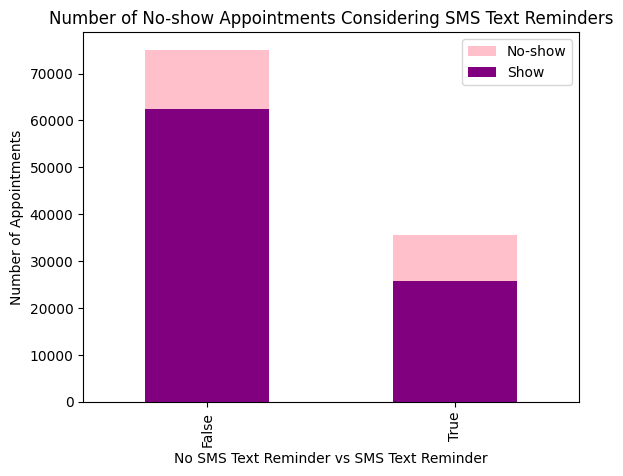

In [25]:
# Plots the number of no-show/show appts by patients who did and did not receive text reminders 
no_show = df['SMS_received'].value_counts()
show = df[df['No-show'] == 0]['SMS_received'].value_counts()
no_show.plot(kind='bar', color='pink')
show.plot(kind='bar', color='purple')
plt.legend(['No-show', 'Show'])
plt.title('Number of No-show Appointments Considering SMS Text Reminders')
plt.xlabel('No SMS Text Reminder vs SMS Text Reminder')
plt.ylabel('Number of Appointments')
plt.show()

> This bar chart shows that patients who did not receive SMS text reminders have more appointments than patients that did receive SMS text reminders. For patients that did not receive SMS text reminders, it shows that there are more attended appointments than no-show appointments. For patients that did not receive SMS text reminders, it shows that there are more attended appointments than no-show appointments. 